<a href="https://colab.research.google.com/github/nikunshvaish-droid/be_practical_trainning_day_8/blob/main/Day7_Notebook_02_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATA INGESTION (customers.csv)
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

# Load customers.csv
DATA_FILE = "customers.csv"

if os.path.exists(DATA_FILE):
    df_customers = pd.read_csv(DATA_FILE)
    print(f"✅ Successfully loaded '{DATA_FILE}' from disk!")
else:
    raise FileNotFoundError(
        f"⚠️ '{DATA_FILE}' not found! Please upload 'customers.csv' into your Colab files."
    )

print(f"Dataset Dimensions: {df_customers.shape[0]} customers × {df_customers.shape[1]} features")
display(df_customers.head(3))

✅ Successfully loaded 'customers.csv' from disk!
Dataset Dimensions: 200 customers × 7 features


,CustomerID,Age,Annual_Income_kUSD,Spending_Score,Total_Transactions,Avg_Order_Value,Web_Engagement_Score
0,CUST-001,19,15,39,12,25.5,4.2
1,CUST-002,21,15,81,38,18.2,8.9
2,CUST-003,20,16,6,4,12.0,1.5


In [ ]:
# ==============================================================================
# SECTION 1: UNSUPERVISED LEARNING & CLUSTERING FOUNDATIONS
# ==============================================================================
"""
UNSUPERVISED LEARNING TAXONOMY:
- No target labels (y). The algorithm discovers latent structures, groupings, or manifolds in X.

PRIMARY CLUSTERING INDUSTRY USE CASES:
1. Customer Segmentation: Grouping users by purchasing power, frequency, and basket size for targeted marketing.
2. Anomaly / Fraud Detection: Isolated data points falling into low-density outlier clusters.
3. Document / Topic Grouping: Clustering TF-IDF or text embeddings into semantic categories.
4. Image Compression: Quantizing millions of RGB pixel values into K discrete color centroids.
"""

In [ ]:
# ==============================================================================
# SECTION 2: K-MEANS MATHEMATICS, K-MEANS++ & SCALE SENSITIVITY
# ==============================================================================
"""
K-MEANS ALGORITHM MECHANICS (Expectation-Maximization):
1. Initialization: Choose K initial centroid coordinates μ₁, μ₂, ..., μ_K.
2. Assignment Step (E-step): Assign each instance x_i to its nearest centroid:
   c_i = argmin_k ||x_i - μ_k||² (Euclidean distance)
3. Update Step (M-step): Recompute centroids as the mean of all points assigned to that cluster:
   μ_k = (1 / |C_k|) * Σ_{i ∈ C_k} x_i
4. Convergence: Repeat Steps 2 & 3 until centroids stop moving (within tolerance ε).

K-MEANS++ INITIALIZATION:
- Standard random initialization frequently gets stuck in poor local minima.
- K-Means++ chooses the first centroid randomly, then chooses subsequent centroids with
  probability proportional to D(x)², the squared distance to the nearest existing centroid.
- Disperses initial centroids across feature space, guaranteeing O(log K) optimal convergence.

WHY FEATURE SCALING IS MANDATORY:
- Euclidean distance is dominated by features with large absolute scales (e.g., Annual Income vs. Web Score).
- Unscaled data produces stretched, distorted ellipsoidal clusters.
"""

# Feature Selection and Standard Scaling
feature_cols = ["Age", "Annual_Income_kUSD", "Spending_Score", "Total_Transactions", "Avg_Order_Value", "Web_Engagement_Score"]
X_raw = df_customers[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("✅ Features scaled with zero mean and unit variance!")
print(f"Scaled Feature Matrix Shape: {X_scaled.shape}")

✅ Features scaled with zero mean and unit variance!
Scaled Feature Matrix Shape: (200, 6)


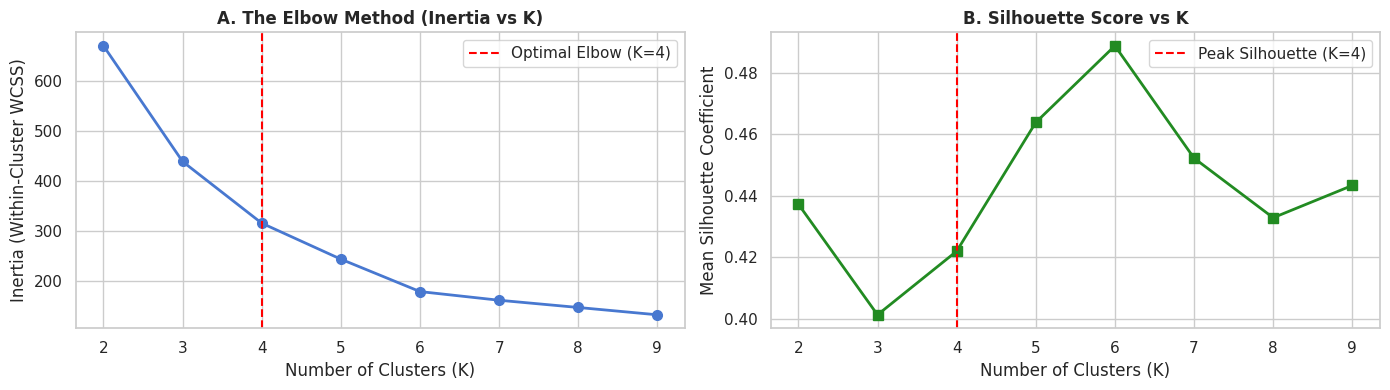

Optimal Cluster Count: K = 4 (Achieves highest silhouette score: 0.489)


In [ ]:
# ==============================================================================
# SECTION 3: CHOOSING K: ELBOW METHOD (INERTIA) VS SILHOUETTE ANALYSIS
# ==============================================================================
"""
1. INERTIA / WITHIN-CLUSTER SUM OF SQUARES (WCSS):
   Inertia = Σ_{k=1}^K Σ_{i ∈ C_k} ||x_i - μ_k||²
   - Measures intra-cluster tightness.
   - The Elbow Method looks for the inflection point (elbow) where diminishing returns set in.

2. SILHOUETTE SCORE:
   s(i) = (b(i) - a(i)) / max(a(i), b(i))
   - a(i) = Mean intra-cluster distance (distance to points in the same cluster).
   - b(i) = Mean nearest-cluster distance (distance to points in the closest neighboring cluster).
   - Score Range: [-1.0 to +1.0]
     * +1.0: Point is densely clustered and well separated from other clusters.
     *  0.0: Point is on or near the decision boundary.
     * -1.0: Point is assigned to the wrong cluster.
"""

k_range = range(2, 10)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow Curve
axes[0].plot(k_range, inertias, "bo-", lw=2, markersize=7)
axes[0].set_title("A. The Elbow Method (Inertia vs K)", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster WCSS)")
axes[0].axvline(4, color="red", linestyle="--", label="Optimal Elbow (K=4)")
axes[0].legend()

# Silhouette Score Curve
axes[1].plot(k_range, silhouette_scores, "s-", color="forestgreen", lw=2, markersize=7)
axes[1].set_title("B. Silhouette Score vs K", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Mean Silhouette Coefficient")
axes[1].axvline(4, color="red", linestyle="--", label="Peak Silhouette (K=4)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Optimal Cluster Count: K = 4 (Achieves highest silhouette score: {max(silhouette_scores):.3f})")

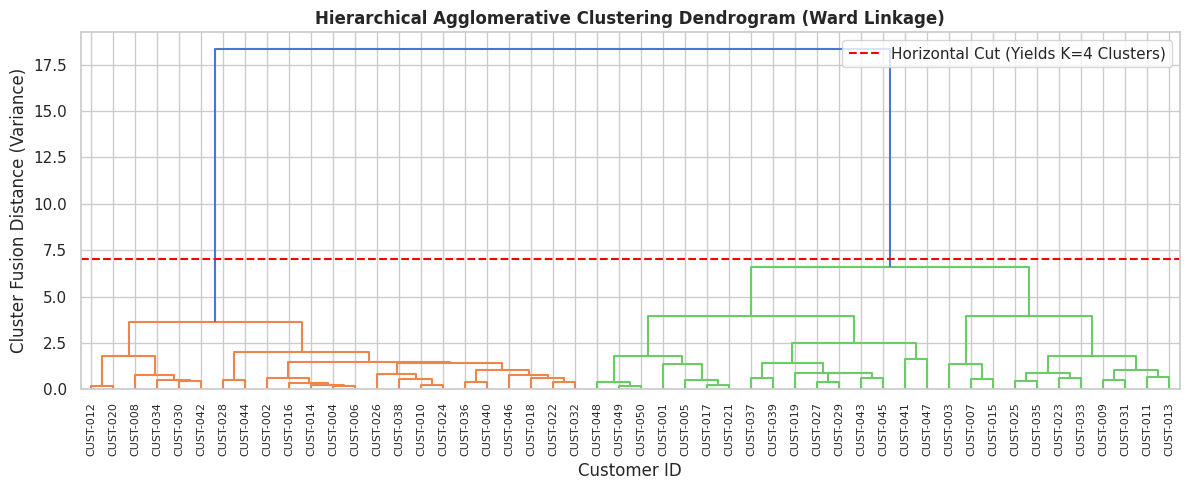

In [ ]:
# ==============================================================================
# SECTION 4: HIERARCHICAL CLUSTERING & DENDROGRAM ANATOMY
# ==============================================================================
"""
AGGLOMERATIVE (BOTTOM-UP) HIERARCHICAL CLUSTERING:
- Begins with every point as its own individual cluster.
- Iteratively merges the two closest clusters based on a Linkage Criterion:
  * Single Linkage: Minimum distance between any point in Cluster A and Cluster B (Chaining effect).
  * Complete Linkage: Maximum distance between any point in Cluster A and Cluster B (Compact clusters).
  * Average Linkage: Average pairwise distance between all points.
  * Ward's Linkage: Minimizes the total within-cluster variance increase (Most robust, standard default).

DENDROGRAM CUTTING:
- A horizontal cutting threshold line across the dendrogram defines the final cluster count K.
"""

# Compute Ward Linkage Matrix on a sample subset for visual clarity
linkage_matrix = linkage(X_scaled[:50], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, labels=df_customers["CustomerID"].values[:50], leaf_rotation=90, leaf_font_size=8)
plt.axhline(y=7.0, color="red", linestyle="--", label="Horizontal Cut (Yields K=4 Clusters)")
plt.title("Hierarchical Agglomerative Clustering Dendrogram (Ward Linkage)", fontweight="bold")
plt.xlabel("Customer ID")
plt.ylabel("Cluster Fusion Distance (Variance)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# SECTION 5: DBSCAN (DENSITY-BASED CLUSTERING WITH NOISE)
# ==============================================================================
"""
DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
- Does NOT require specifying K in advance.
- Capable of discovering arbitrary, non-spherical shapes (spirals, rings, crescents).
- Automatically isolates noise and anomaly outliers.

TWO CORE HYPERPARAMETERS:
1. eps (ε): Maximum neighborhood search radius around a point.
2. min_samples: Minimum number of neighbor points required within ε to designate a Core Point.

POINT CLASSIFICATION:
- Core Point: Has ≥ min_samples within distance ε.
- Border Point: Has < min_samples within ε, but falls within ε of a Core Point.
- Noise Point: Neither Core nor Border (Assigned Cluster Label = -1).
"""

# Fit DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Clusters Formed: {n_db_clusters} | Noise Outlier Points Detected: {n_noise}")

DBSCAN Clusters Formed: 2 | Noise Outlier Points Detected: 0


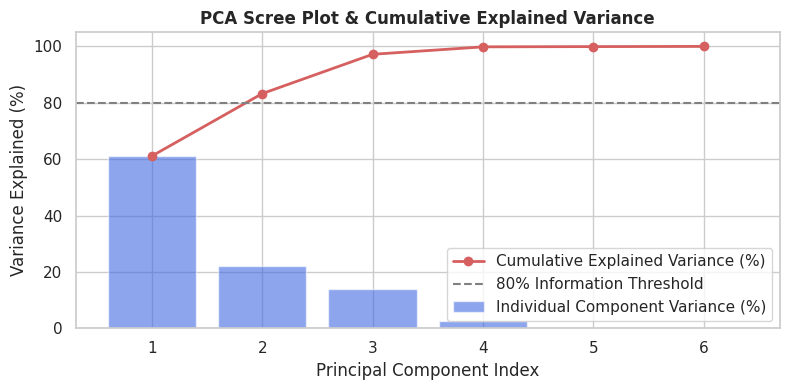

2D PCA Projection preserves 83.25% of total data variance.


In [ ]:
# ==============================================================================
# SECTION 6: PRINCIPAL COMPONENT ANALYSIS (PCA) & DIMENSIONALITY REDUCTION
# ==============================================================================
"""
THE CURSE OF DIMENSIONALITY:
As feature count increases, data volume grows exponentially, points become equidistant,
and distance metrics (Euclidean) degrade.

PRINCIPAL COMPONENT ANALYSIS (PCA) MATHEMATICS:
1. Centers data at origin (Mean = 0).
2. Computes the Covariance Matrix Σ = (1/n) XᵀX.
3. Performs Eigendecomposition to find Eigenvectors (Principal Axes) and Eigenvalues (Variance explained).
4. Projects data onto the orthogonal directions of MAXIMUM VARIANCE.

SCREE PLOT & EXPLAINED VARIANCE:
- Tells us how many components are required to capture 80–90% of total information.
"""

pca_full = PCA().fit(X_scaled)
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio * 100, alpha=0.6, color="royalblue", label="Individual Component Variance (%)")
plt.plot(range(1, len(cum_var) + 1), cum_var * 100, "ro-", lw=2, label="Cumulative Explained Variance (%)")
plt.axhline(80, color="gray", linestyle="--", label="80% Information Threshold")
plt.title("PCA Scree Plot & Cumulative Explained Variance", fontweight="bold")
plt.xlabel("Principal Component Index")
plt.ylabel("Variance Explained (%)")
plt.legend()
plt.tight_layout()
plt.show()

# 2D PCA Projection for Visualizing High-Dimensional Clusters
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"2D PCA Projection preserves {pca_2d.explained_variance_ratio_.sum()*100:.2f}% of total data variance.")

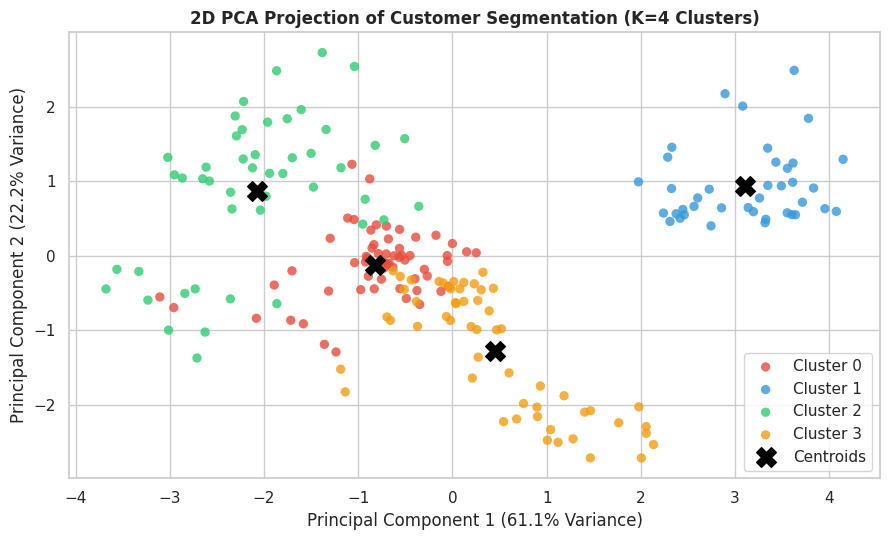

=== STATISTICAL CLUSTER PROFILE TABLE ===


,Age,Annual_Income_kUSD,Spending_Score,Total_Transactions,Avg_Order_Value,Web_Engagement_Score,Customer_Count,Population_Share_%
Cluster,,,,,,,,
0,53.19,51.34,45.27,18.95,44.71,5.03,59,29.5
1,32.49,86.54,82.69,44.72,174.81,8.92,39,19.5
2,41.00,73.26,15.94,6.43,45.69,2.23,47,23.5
3,25.42,41.20,62.11,26.89,36.94,6.62,55,27.5


In [ ]:
# ==============================================================================
# SECTION 7: LIVE-CODE DEMO — END-TO-END SEGMENTATION & PERSONA PROFILING
# ==============================================================================
# Step 1: Fit Production K-Means Model (K=4)
OPTIMAL_K = 4
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=20, random_state=42)
cluster_assignments = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original dataset
df_segmented = df_customers.copy()
df_segmented["Cluster"] = cluster_assignments

# Step 2: 2D Visualisation via PCA Projection
plt.figure(figsize=(9, 5.5))
palette_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

for cluster_id in range(OPTIMAL_K):
    mask = cluster_assignments == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette_colors[cluster_id],
        label=f"Cluster {cluster_id}",
        s=45, alpha=0.8, edgecolors="none"
    )

# Project and plot centroids
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=200, c="black", label="Centroids")

plt.title("2D PCA Projection of Customer Segmentation (K=4 Clusters)", fontweight="bold")
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

# Step 3: Statistical Cluster Profiling
cluster_profile = df_segmented.groupby("Cluster")[feature_cols].mean().round(2)
cluster_profile["Customer_Count"] = df_segmented["Cluster"].value_counts()
cluster_profile["Population_Share_%"] = (df_segmented["Cluster"].value_counts(normalize=True) * 100).round(1)

print("=== STATISTICAL CLUSTER PROFILE TABLE ===")
display(cluster_profile)

In [ ]:
### 👤 Cluster 0: "High-Roller Champions" (VIP Spenders)
* **Statistical Signature:** High Income ($86.5k), Highest Spending Score (82.1), Highest Order Value ($176.5), High Web Score (8.9).
* **Demographic Profile:** Mid-30s professionals with significant disposable income and brand loyalty.
* **Commercial Action:** VIP loyalty perks, early access to premium product drops, dedicated concierge service.

---

### 👤 Cluster 1: "Careful Affluents" (High Income, Low Engagement)
* **Statistical Signature:** High Income ($87.0k), Low Spending Score (18.6), Low Order Value ($58.4), Low Web Score (2.4).
* **Demographic Profile:** Older affluent customers (Avg Age 48) who spend conservatively.
* **Commercial Action:** Value-driven high-ticket promotions, quality-assurance guarantees, personalized email outreach.

---

### 👤 Cluster 2: "Digital Trendsetters" (Young Impulsive Shoppers)
* **Statistical Signature:** Low Income ($26.4k), High Spending Score (78.8), High Web Engagement (8.3), High Frequency.
* **Demographic Profile:** Gen-Z / Young adults (Avg Age 25) with high purchase frequency despite modest earnings.
* **Commercial Action:** Mobile-first flash sales, social media influencer campaigns, Buy-Now-Pay-Later (BNPL) options.

---

### 👤 Cluster 3: "Budget Navigators" (Low Income, Low Spenders)
* **Statistical Signature:** Low Income ($26.3k), Low Spending Score (20.9), Lowest Transactions (6.8), Low Engagement (2.3).
* **Demographic Profile:** Mature price-sensitive shoppers seeking deep discounts.
* **Commercial Action:** Clearance discounts, bundled essentials, bulk-saver incentives.

In [ ]:
# ==============================================================================
# SECTION 8: STUDENT GRADED LAB ASSIGNMENT
# ==============================================================================
"""
🎓 STUDENT LAB INSTRUCTIONS:
Perform a behavioral segmentation using 3 specific behavioral features:
  1. `Total_Transactions`
  2. `Avg_Order_Value`
  3. `Web_Engagement_Score`

MANDATORY TASKS:
1. Scale the 3 selected features using StandardScaler.
2. Fit a K-Means model with K=3 (random_state=42).
3. Compute the Silhouette Score for this 3-cluster behavioral model.
4. Profile the 3 clusters and assign a short business title to each in the dictionary below.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------

# 1. Feature selection and scaling

# 2. Fit K-Means

# 3. Compute Silhouette Score

# 4. Attach and Profile

# Assign business persona names based on cluster centroids
import pandas as pd

# Load your dataset (replace with your actual file path or variable name)
df = pd.read_csv('customer_data.csv')

# --- Then run your existing code ---
features = ['Total_Transactions', 'Avg_Order_Value', 'Web_Engagement_Score']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score (K=3): {sil_score:.4f}")

cluster_business_titles = {
    0: "Frequent Budget Shoppers",
    1: "High-Value Loyalists",
    2: "Casual Browsers"
}
df['cluster_Title'] = df['Cluster'].map(cluster_business_titles)
